# County-Level Broadband Access in the United States
### Analysis workflow

This notebook walks through the analysis behind the project summary and report:
why each step was run, what it showed, and how it shaped the next step. Every
statistic printed here is the value used in the written documents, so the
analysis is fully reproducible from the public county-level extract.

**Question.** National and state averages suggest most of the U.S. is online.
Do county-level data tell the same story, and what actually predicts whether a
county's households are connected — infrastructure, or economic conditions?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})
INK, ACC, GRN = "#1b3a5b", "#c0392b", "#2e7d52"
pd.set_option("display.width", 100)

## 1. Load and clean

The raw extract has 3,142 rows. Cleaning mirrors the original RapidMiner
workflow. The two judgment calls worth noting: (1) the IMLS cost field is kept
over the BroadbandNow price column because the two measured the same quantity
and IMLS is more authoritative; (2) the BroadbandNow provider count is dropped
because it averaged ~12 providers per county — roughly triple the FCC national
average near 4 — which is implausible and would distort any infrastructure
comparison.

In [2]:
df = pd.read_csv("data/broadband_access.csv", encoding="latin1")
print("Raw shape:", df.shape)

# Drop the redundant BBN price column and the 40 rows (1.3%) with no IMLS cost.
df = df.drop(columns=["Lowestpricepermonth_bbn"]).dropna(subset=["broad_cost"])

# Mean-impute five near-complete continuous fields (<0.5% missing each).
for c in ["wired_bbn", "all25_bbn", "downave_bbn", "access_bbn", "slowfrac_bbn"]:
    df[c] = df[c].fillna(df[c].mean())

# Fill the two single-county gaps from public reference values.
df["unemp_19%"] = df["unemp_19%"].fillna(21.0)         # Kalawao County, HI
df["poverty_rate%"] = df["poverty_rate%"].fillna(24.0) # Rio Arriba County, NM

# Drop BBN population and provider columns superseded by IMLS equivalents.
df = df.drop(columns=["population_bbn", "provide_bbn"])
print("Clean shape:", df.shape, "(counties x variables)")
print("Remaining missing values:", int(df.isnull().sum().sum()))

Raw shape: (3142, 23)
Clean shape: (3102, 20) (counties x variables)
Remaining missing values: 0


## 2. How wide is the gap that averages hide?

Before modeling anything, look at the spread of the outcome. If county adoption
were tightly clustered, state averages would be a fair summary. They are not.

Median home broadband: 73.7%
5th-95th percentile:  55.8% - 86.5%
Full range:           25.7% - 95.5%  (69.8 pts)


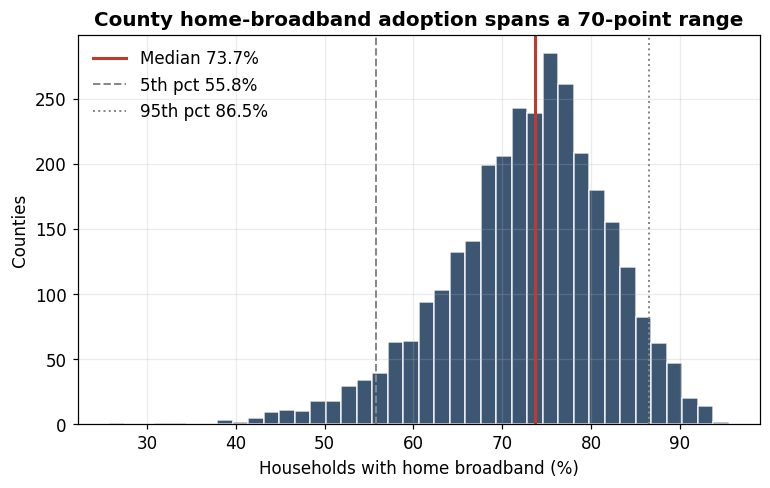

In [3]:
hb = df["home_havebroad%"]
print(f"Median home broadband: {hb.median():.1f}%")
print(f"5th-95th percentile:  {hb.quantile(.05):.1f}% - {hb.quantile(.95):.1f}%")
print(f"Full range:           {hb.min():.1f}% - {hb.max():.1f}%  ({hb.max()-hb.min():.1f} pts)")

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(hb, bins=40, color=INK, alpha=0.85, edgecolor="white")
ax.axvline(hb.median(), color=ACC, lw=2, label=f"Median {hb.median():.1f}%")
ax.axvline(hb.quantile(.05), color="#888", ls="--", lw=1.3, label=f"5th pct {hb.quantile(.05):.1f}%")
ax.axvline(hb.quantile(.95), color="#888", ls=":", lw=1.3, label=f"95th pct {hb.quantile(.95):.1f}%")
ax.set(title="County home-broadband adoption spans a 70-point range",
       xlabel="Households with home broadband (%)", ylabel="Counties")
ax.legend(frameon=False); plt.show()

The median county sits at **73.7%**, but counties span from **25.7%** to
**95.5%** — a ~70-point range. The bottom 5% of counties are below 56%. This
spread is the whole motivation for working at the county level: a single
national figure averages a connected county with one where a quarter of homes
are online.

## 3. What predicts adoption — infrastructure or economics?

Compare each candidate factor's correlation with actual home-broadband
adoption. The contrast that matters is **poverty** (an economic/affordability
signal) against **formal availability** (an infrastructure-coverage signal).

  Poverty rate         r = -0.650
  SNAP receipt         r = -0.567
  Avg download speed   r = +0.462
  No health insurance  r = -0.409
  Unemployment         r = -0.380
  Formal availability  r = +0.300
  Provider count       r = +0.222
  Monthly cost         r = +0.037

Poverty |r| (0.65) is more than double availability |r| (0.30).


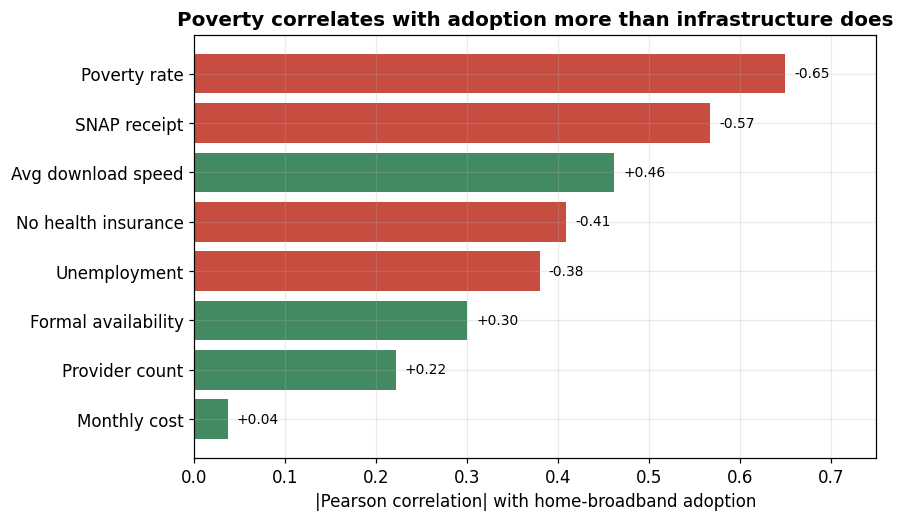

In [4]:
factors = {"Poverty rate":"poverty_rate%", "SNAP receipt":"SNAP_recieved%",
           "Avg download speed":"downave_bbn", "No health insurance":"nohealth_ins%",
           "Unemployment":"unemp_19%", "Formal availability":"broad_avail",
           "Provider count":"broadProviders_num", "Monthly cost":"broad_cost"}
corr = {k: hb.corr(df[v]) for k, v in factors.items()}
for k, r in sorted(corr.items(), key=lambda t: -abs(t[1])):
    print(f"  {k:20s} r = {r:+.3f}")
print(f"\nPoverty |r| ({abs(corr['Poverty rate']):.2f}) is more than double "
      f"availability |r| ({abs(corr['Formal availability']):.2f}).")

rows = sorted(corr.items(), key=lambda t: abs(t[1]))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([r[0] for r in rows], [abs(r[1]) for r in rows],
        color=[GRN if r[1] > 0 else ACC for r in rows], alpha=0.9)
for i, (_, v) in enumerate(rows): ax.text(abs(v)+0.01, i, f"{v:+.2f}", va="center", fontsize=9)
ax.set(title="Poverty correlates with adoption more than infrastructure does",
       xlabel="|Pearson correlation| with home-broadband adoption", xlim=(0, 0.75)); plt.show()

**Poverty** is the strongest correlate (r = -0.65), with SNAP receipt close
behind (r = -0.57). Formal availability — whether providers nominally serve the
county — correlates only weakly (r = +0.30), and raw provider count weaker still
(r = +0.22). Monthly cost is essentially flat (r = +0.04). The signal pointing
to where households are actually offline is economic, not infrastructural.

## 4. The poverty relationship up close

A scatter confirms the correlation is a real gradient, not an artifact of a few
outliers.

OLS slope: -0.93 broadband points per +1 point of poverty (r = -0.65)


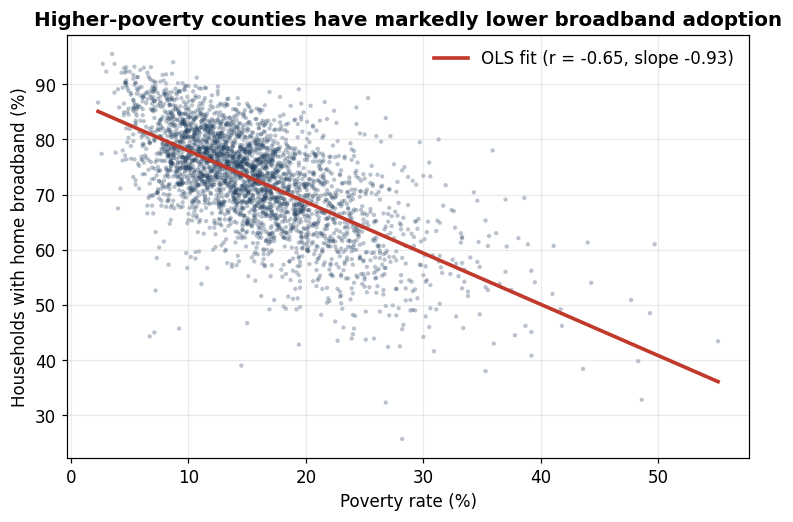

In [5]:
x, y = df["poverty_rate%"], hb
b, a = np.polyfit(x, y, 1)
print(f"OLS slope: {b:.2f} broadband points per +1 point of poverty (r = {x.corr(y):.2f})")
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=8, alpha=0.30, color=INK, edgecolors="none")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a + b*xs, color=ACC, lw=2.4, label=f"OLS fit (r = {x.corr(y):.2f}, slope {b:.2f})")
ax.set(title="Higher-poverty counties have markedly lower broadband adoption",
       xlabel="Poverty rate (%)", ylabel="Households with home broadband (%)")
ax.legend(frameon=False); plt.show()

Each additional point of county poverty is associated with roughly a
**0.9-point** drop in home-broadband adoption. The band tightens the conclusion:
this is a population-wide gradient across all 3,102 counties.

## 5. Socioeconomic equity: adoption by poverty quartile

Binning counties into poverty quartiles turns the gradient into a plain-language
gap.

*Note on scope:* the original Tableau story layered a county racial-composition
overlay (joined separately) to examine racial equity. That overlay is **not**
part of this public extract, so this write-up analyzes the socioeconomic equity
dimension the published data can support directly.

            size  mean  median
q                             
Q1 lowest    777  79.2    79.4
Q2           782  75.6    76.0
Q3           782  71.8    72.2
Q4 highest   761  64.3    64.7

Q1 vs Q4 adoption gap: 14.9 points


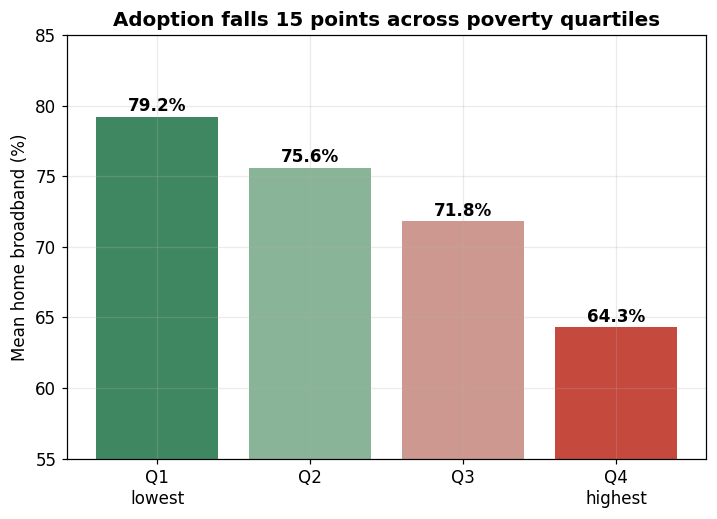

In [6]:
d = df.copy()
d["q"] = pd.qcut(d["poverty_rate%"], 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
tab = d.groupby("q", observed=True)["home_havebroad%"].agg(["size","mean","median"]).round(1)
print(tab.to_string())
gap = tab.loc["Q1 lowest","mean"] - tab.loc["Q4 highest","mean"]
print(f"\nQ1 vs Q4 adoption gap: {gap:.1f} points")

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(["Q1\nlowest","Q2","Q3","Q4\nhighest"], tab["mean"],
              color=[GRN,"#7fae8f","#c98f86",ACC], alpha=0.92)
for bb,v in zip(bars,tab["mean"]): ax.text(bb.get_x()+bb.get_width()/2, v+0.4, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set(title=f"Adoption falls {gap:.0f} points across poverty quartiles",
       ylabel="Mean home broadband (%)", ylim=(55,85)); plt.show()

Adoption steps down monotonically from **79.2%** in the lowest-poverty
quartile to **64.3%** in the highest — a **15-point** gap that maps the digital
divide onto economic disadvantage.

## 6. Availability is not adoption

Policy often measures success by whether providers *serve* an area. Plotting
formal availability against actual adoption tests whether coverage guarantees
connection.

Counties with >=90% formal availability: 1044
  their mean adoption:  76.1%
  their lowest adoption: 39.0%


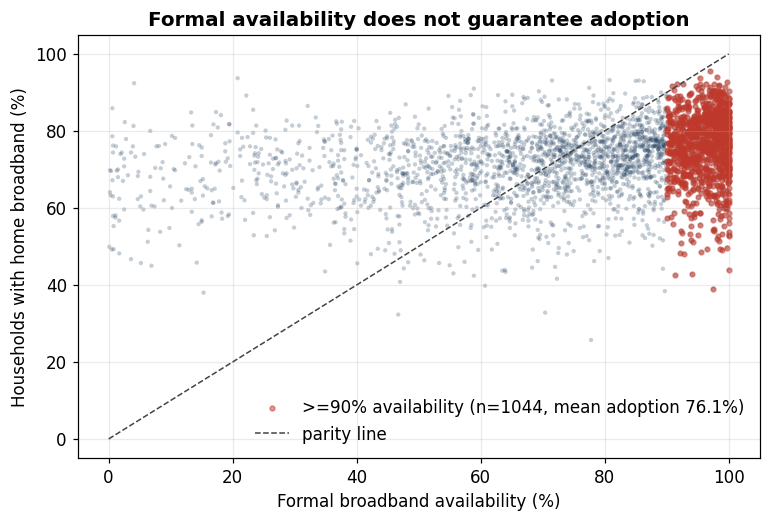

In [7]:
hi = df[df["broad_avail"] >= 90]
print(f"Counties with >=90% formal availability: {len(hi)}")
print(f"  their mean adoption:  {hi['home_havebroad%'].mean():.1f}%")
print(f"  their lowest adoption: {hi['home_havebroad%'].min():.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["broad_avail"], hb, s=8, alpha=0.25, color=INK, edgecolors="none")
ax.scatter(hi["broad_avail"], hi["home_havebroad%"], s=10, alpha=0.5, color=ACC,
           label=f">=90% availability (n={len(hi)}, mean adoption {hi['home_havebroad%'].mean():.1f}%)")
ax.plot([0,100],[0,100], color="#444", ls="--", lw=1, label="parity line")
ax.set(title="Formal availability does not guarantee adoption",
       xlabel="Formal broadband availability (%)", ylabel="Households with home broadband (%)")
ax.legend(frameon=False, loc="lower right"); plt.show()

Among the **1,044** counties with formal availability at or above 90%,
mean household adoption is still only **76.1%**, and the worst sits at **39%**.
Coverage maps overstate connection: in counties that are nominally fully served,
roughly one household in four is still offline.

## 7. Regional gradient

Aggregating to Census region summarizes the geography.

           size  mean
region               
South      1390  69.2
Midwest    1050  74.4
West        445  76.8
Northeast   217  79.2


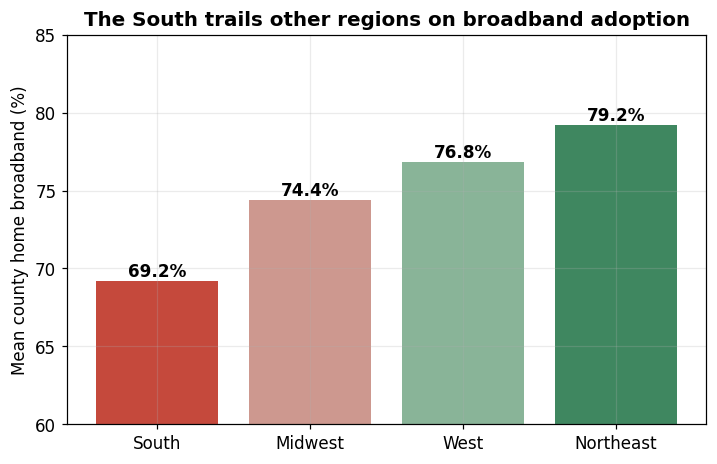

In [8]:
NE={"Connecticut","Maine","Massachusetts","New Hampshire","Rhode Island","Vermont","New Jersey","New York","Pennsylvania"}
MW={"Illinois","Indiana","Michigan","Ohio","Wisconsin","Iowa","Kansas","Minnesota","Missouri","Nebraska","North Dakota","South Dakota"}
S={"Delaware","Florida","Georgia","Maryland","North Carolina","South Carolina","Virginia","West Virginia","District of Columbia","Alabama","Kentucky","Mississippi","Tennessee","Arkansas","Louisiana","Oklahoma","Texas"}
W={"Arizona","Colorado","Idaho","Montana","Nevada","New Mexico","Utah","Wyoming","Alaska","California","Hawaii","Oregon","Washington"}
def region(s): return "Northeast" if s in NE else "Midwest" if s in MW else "South" if s in S else "West" if s in W else "Other"
d=df.copy(); d["region"]=d["state"].map(region)
reg=d.groupby("region")["home_havebroad%"].agg(["size","mean"]).round(1).sort_values("mean")
print(reg.to_string())

m=reg["mean"]
fig, ax = plt.subplots(figsize=(7.5,4.6))
bars=ax.bar(m.index, m.values, color=[ACC,"#c98f86","#7fae8f",GRN], alpha=0.92)
for bb,v in zip(bars,m.values): ax.text(bb.get_x()+bb.get_width()/2, v+0.3, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set(title="The South trails other regions on broadband adoption",
       ylabel="Mean county home broadband (%)", ylim=(60,85)); plt.show()

The **South** trails at **69.2%** mean county adoption (n=1,390), about
**10 points** below the Northeast (79.2%). The lowest-adoption states —
Mississippi (61.1%), New Mexico (63.2%), Arkansas (64.2%) — cluster in the
Deep South and the rural Southwest, the same places where poverty is highest.

## 8. Synthesis

Three findings hold across the 3,102-county dataset: county adoption varies
enormously (a 70-point range the averages hide); **economic conditions predict
adoption far better than infrastructure metrics** (poverty r = -0.65 vs.
availability r = +0.30); and **formal availability overstates real access** —
1,044 fully-covered counties still average only 76% adoption. The gap is
concentrated in high-poverty, Southern, and rural counties. Programs aimed at
closing it should target affordability and adoption support in economically
disadvantaged counties, not only infrastructure buildout in areas already
nominally served.